In [1]:
import sys
import torch

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Torch:", torch.__version__)
print("Torch path:", torch.__file__)

Python: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
Executable: c:\Program Files\Python312\python.exe
Torch: 2.13.0+cpu
Torch path: C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\torch\__init__.py


Cell 1 — Generate the dataset

In [8]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src/data").resolve()))
sys.path.append(str(Path("../src/physics").resolve()))

from generate_dataset import generate_dataset

splits, metadata = generate_dataset(
    n_samples = 10_000,
    N         = 64,
    alpha     = 0.01,
    stride    = 10,
    max_blobs = 3,
    seed      = 42,
    save_path = "../data/heat_dataset.npz",
)

Dataset Generation Parameters
  Samples       : 10000
  Grid          : 64 x 64
  alpha         : 0.01
  dx            : 0.015873
  dt            : 0.005669
  Fourier r     : 0.2250  (<= 0.25 required)
  Stride        : 10 steps
  Physical Δt   : 0.056689 per CNN step
  Max blobs     : 3
  Random seed   : 42
  Generating sample      0 / 10000 ...
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (mu

Cell 2 — Verify shapes and values

In [9]:
import numpy as np

for split_name in ["train", "val", "test"]:
    inp = splits[f"{split_name}_inputs"]
    tgt = splits[f"{split_name}_targets"]
    print(f"{split_name}:")
    print(f"  inputs  shape={inp.shape}  dtype={inp.dtype}  "
          f"min={inp.min():.4f}  max={inp.max():.4f}")
    print(f"  targets shape={tgt.shape}  dtype={tgt.dtype}  "
          f"min={tgt.min():.4f}  max={tgt.max():.4f}")

train:
  inputs  shape=(8000, 64, 64)  dtype=float32  min=0.0000  max=1.0000
  targets shape=(8000, 64, 64)  dtype=float32  min=0.0000  max=1.0000
val:
  inputs  shape=(1000, 64, 64)  dtype=float32  min=0.0000  max=1.0000
  targets shape=(1000, 64, 64)  dtype=float32  min=0.0000  max=1.0000
test:
  inputs  shape=(1000, 64, 64)  dtype=float32  min=0.0000  max=1.0000
  targets shape=(1000, 64, 64)  dtype=float32  min=0.0000  max=1.0000


Cell 3 — Visualize random examples

C:\Users\adity\AppData\Local\Temp\ipykernel_43300\2920659629.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


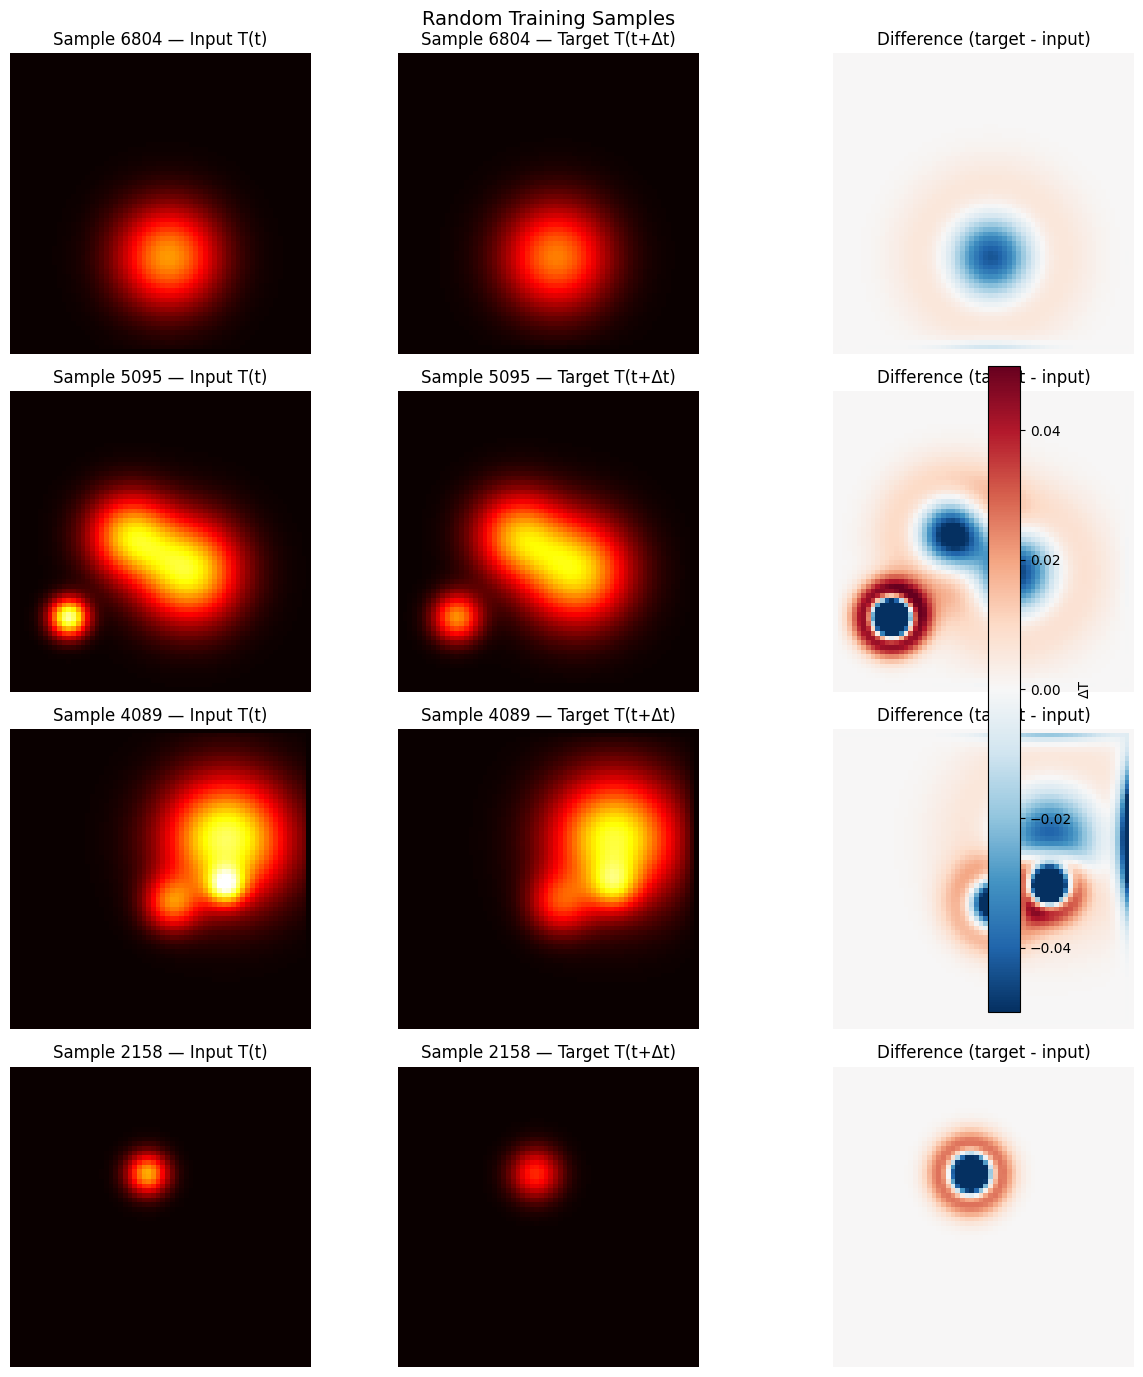

In [10]:
import matplotlib.pyplot as plt
import numpy as np

rng_vis = np.random.default_rng(0)
indices = rng_vis.integers(0, len(splits["train_inputs"]), size=4)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for row, idx in enumerate(indices):
    inp = splits["train_inputs"][idx]
    tgt = splits["train_targets"][idx]
    err = tgt - inp   # difference field

    vmin, vmax = 0.0, 1.0

    axes[row, 0].imshow(inp, origin="lower", cmap="hot", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Sample {idx} — Input T(t)")

    axes[row, 1].imshow(tgt, origin="lower", cmap="hot", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"Sample {idx} — Target T(t+Δt)")

    # difference: where did temperature change?
    im = axes[row, 2].imshow(err, origin="lower", cmap="RdBu_r",
                              vmin=-0.05, vmax=0.05)
    axes[row, 2].set_title("Difference (target - input)")

for ax in axes.flatten():
    ax.axis("off")

fig.colorbar(im, ax=axes[:, 2], shrink=0.6, label="ΔT")
plt.suptitle("Random Training Samples", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone3_samples.png", dpi=150)
plt.show()

Cell 4 — Check reproducibility

In [11]:
# generate a second dataset with the same seed — should be byte-identical
from generate_dataset import generate_dataset

splits2, _ = generate_dataset(
    n_samples=100,   # small for speed
    N=64, alpha=0.01, stride=10, max_blobs=3,
    seed=42,
    save_path="../data/heat_dataset_repro_check.npz"
)

splits1_small, _ = generate_dataset(
    n_samples=100,
    N=64, alpha=0.01, stride=10, max_blobs=3,
    seed=42,
    save_path="../data/heat_dataset_repro_check2.npz"
)

match = np.allclose(
    splits1_small["train_inputs"],
    splits2["train_inputs"]
)
print(f"✓ Reproducibility check: datasets identical = {match}")
assert match, "Datasets differ despite same seed — check your RNG usage!"

Dataset Generation Parameters
  Samples       : 100
  Grid          : 64 x 64
  alpha         : 0.01
  dx            : 0.015873
  dt            : 0.005669
  Fourier r     : 0.2250  (<= 0.25 required)
  Stride        : 10 steps
  Physical Δt   : 0.056689 per CNN step
  Max blobs     : 3
  Random seed   : 42
  Generating sample      0 / 100 ...
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must b

Cell 5 — Verify the PyTorch Dataset wrapper

In [12]:
sys.path.append(str(Path("../src/data").resolve()))
from dataset import load_dataset

train_ds, val_ds, test_ds, meta = load_dataset("../data/heat_dataset.npz")

# check a single item
inp_tensor, tgt_tensor = train_ds[0]
print(f"Input tensor shape  : {inp_tensor.shape}")   # expect torch.Size([1, 64, 64])
print(f"Target tensor shape : {tgt_tensor.shape}")   # expect torch.Size([1, 64, 64])
print(f"Input dtype         : {inp_tensor.dtype}")   # expect torch.float32
print(f"Input value range   : [{inp_tensor.min():.4f}, {inp_tensor.max():.4f}]")

Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}
Input tensor shape  : torch.Size([1, 64, 64])
Target tensor shape : torch.Size([1, 64, 64])
Input dtype         : torch.float32
Input value range   : [0.0000, 0.9741]
